# Load the Dataset

In [10]:
import os
import pandas as pd
from PIL import Image

# =====================================================
# 1. PATHS
# =====================================================
IMAGE_FOLDER = r"F:\New_File_Dataset\archive (2)\Tourism Dataset\Tourism Dataset\image"
CSV_PATH = r"F:\New_File_Dataset\archive (2)\tourism_multimodal.csv"

# =====================================================
# 2. LOAD CSV
# =====================================================
df = pd.read_csv(CSV_PATH)

print("✅ CSV Loaded")
print("Shape:", df.shape)

# =====================================================
# 3. SORT IMAGE FILES
# =====================================================
all_images = os.listdir(IMAGE_FOLDER)

valid_ext = ('.jpg', '.jpeg', '.png')
all_images = [img for img in all_images if img.lower().endswith(valid_ext)]

# Sort images (IMPORTANT)
all_images = sorted(all_images)

print("📁 Total images:", len(all_images))

# =====================================================
# 4. TAKE ONLY 18310 SAMPLES
# =====================================================
num_samples = 18310

df_filtered = df.head(num_samples).copy()
selected_images = all_images[:num_samples]

print("\n✅ Using 18310 samples")

# =====================================================
# 5. ADD IMAGE COLUMN (INDEX MATCHING)
# =====================================================
df_filtered['matched_image'] = selected_images

print("Final dataset shape:", df_filtered.shape)

# =====================================================
# 6. DATASET CLASS
# =====================================================
class TourismDataset:
    def __init__(self, dataframe, image_folder):
        self.df = dataframe
        self.image_folder = image_folder

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_name = row['matched_image']
        text = str(row['review_text'])
        rating = row['tourist_rating']

        image_path = os.path.join(self.image_folder, image_name)

        try:
            image = Image.open(image_path).convert("RGB")
        except Exception as e:
            print(f"⚠ Error loading image: {image_path}")
            return None

        return {
            "image": image,
            "text": text,
            "rating": rating
        }

# =====================================================
# 7. CREATE DATASET
# =====================================================
dataset = TourismDataset(df_filtered, IMAGE_FOLDER)

print("\n✅ Dataset Ready")
print("Total Samples:", len(dataset))

# =====================================================
# 8. TEST SAMPLE
# =====================================================
sample = dataset[0]

print("\n🔍 Sample Check:")
print("Text:", sample['text'][:100])
print("Rating:", sample['rating'])

sample['image'].show()

# =====================================================
# 9. SAVE FILTERED DATA
# =====================================================
df_filtered.to_csv("filtered_2000_dataset.csv", index=False)

print("\n💾 Saved filtered dataset")

✅ CSV Loaded
Shape: (18300, 20)
📁 Total images: 18310

✅ Using 18310 samples
Final dataset shape: (18310, 21)

✅ Dataset Ready
Total Samples: 18310

🔍 Sample Check:
Text: Rich culture, but infrastructure needs improvement.
Rating: 0.36

💾 Saved filtered dataset


# Pre-Processing

In [14]:
import torch
from torchvision import transforms
from PIL import ImageFilter
from transformers import BertTokenizer
import numpy as np

# =====================================================
# 1. BERT TOKENIZER
# =====================================================
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# =====================================================
# 2. IMAGE TRANSFORM (Gaussian + Resize + Normalize)
# =====================================================
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.Lambda(lambda img: img.filter(ImageFilter.GaussianBlur(radius=1))),  # Gaussian
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =====================================================
# 3. MIN-MAX NORMALIZATION FUNCTION
# =====================================================
def min_max_normalize(value, min_val, max_val):
    return (value - min_val) / (max_val - min_val + 1e-8)

# Compute rating range
rating_min = df_filtered['tourist_rating'].min()
rating_max = df_filtered['tourist_rating'].max()

print("Rating Min:", rating_min)
print("Rating Max:", rating_max)

# =====================================================
# 4. PREPROCESS FUNCTION
# =====================================================
def preprocess_sample(sample):
    
    # -------------------------
    # IMAGE PROCESSING
    # -------------------------
    image = sample['image']
    image = image_transform(image)
    
    # -------------------------
    # TEXT PROCESSING (BERT)
    # -------------------------
    text = sample['text']
    
    encoding = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].squeeze(0)
    attention_mask = encoding['attention_mask'].squeeze(0)
    
    # -------------------------
    # RATING NORMALIZATION
    # -------------------------
    rating = sample['rating']
    rating_norm = min_max_normalize(rating, rating_min, rating_max)
    rating_tensor = torch.tensor(rating_norm, dtype=torch.float32)
    
    return {
        "image": image,                       # Tensor (3×224×224)
        "input_ids": input_ids,               # BERT input
        "attention_mask": attention_mask,
        "rating": rating_tensor              # normalized
    }

# =====================================================
# 5. APPLY PREPROCESSING
# =====================================================
processed_data = []

for i in range(len(dataset)):
    sample = dataset[i]
    
    if sample is not None:
        processed = preprocess_sample(sample)
        processed_data.append(processed)

print("\nPreprocessing Completed")
print("Total processed samples:", len(processed_data))

# =====================================================
# 6. CHECK OUTPUT
# =====================================================
sample = processed_data[0]

print("\nProcessed Sample Shapes:")
print("Image:", sample['image'].shape)
print("Input IDs:", sample['input_ids'].shape)
print("Attention Mask:", sample['attention_mask'].shape)
print("Rating:", sample['rating'])


Error displaying widget: model not found
C:\Users\S3\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\S3\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Error displaying widget: model not found
Error displaying widget: model not found
Rating Mi

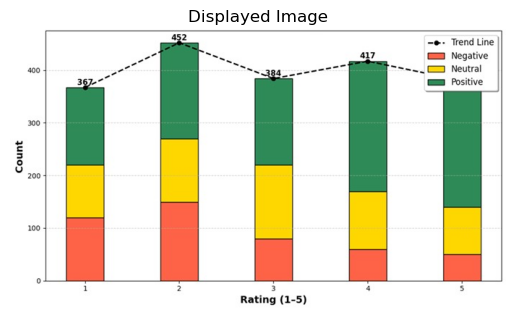

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1. PREPARE DATA
# =====================================================
ratings = sorted(df_filtered['tourist_rating'].unique())

positive_counts = []
negative_counts = []
neutral_counts = []
total_counts = []

for r in ratings:
    subset = df_filtered[df_filtered['tourist_rating'] == r]
    
    pos = (subset['review_sentiment_category'] == 'positive').sum()
    neg = (subset['review_sentiment_category'] == 'negative').sum()
    neu = (subset['review_sentiment_category'] == 'neutral').sum()
    
    total = len(subset)
    
    positive_counts.append(pos)
    negative_counts.append(neg)
    neutral_counts.append(neu)
    total_counts.append(total)

# =====================================================
# 2. PLOT STACKED BAR
# =====================================================
x = np.arange(len(ratings))

plt.figure(figsize=(8,6))

plt.bar(x, negative_counts, label='Negative')
plt.bar(x, neutral_counts, bottom=negative_counts, label='Neutral')
plt.bar(x, positive_counts,
        bottom=np.array(negative_counts) + np.array(neutral_counts),
        label='Positive')

# =====================================================
# 3. TREND LINE
# =====================================================
plt.plot(x, total_counts, linestyle='--', marker='o', label='Trend Line')

# Add values on trend line
for i, val in enumerate(total_counts):
    plt.text(x[i], val + 5, str(val), ha='center')

# =====================================================
# 4. LABELS
# =====================================================
plt.xticks(x, ratings)
plt.xlabel("Rating (1–5)")
plt.ylabel("Count")
plt.title("Distribution of Sentiment Across Ratings")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Feature Extraction

In [17]:
import torch
import torch.nn as nn
from torchvision import models
from transformers import BertModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# 1. LOAD RESNET (IMAGE FEATURE EXTRACTOR)
# =====================================================
resnet = models.resnet50(pretrained=True)

# Remove classification layer (FC)
resnet = nn.Sequential(*list(resnet.children())[:-1])  # remove last layer

resnet = resnet.to(device)
resnet.eval()

# =====================================================
# 2. LOAD BERT (TEXT FEATURE EXTRACTOR)
# =====================================================
bert_model = BertModel.from_pretrained('bert-base-uncased')

bert_model = bert_model.to(device)
bert_model.eval()

# =====================================================
# 3. LATENT SPACE PROJECTION
# =====================================================
LATENT_DIM = 256

image_projection = nn.Linear(2048, LATENT_DIM).to(device)
text_projection = nn.Linear(768, LATENT_DIM).to(device)
rating_projection = nn.Linear(1, LATENT_DIM).to(device)

# =====================================================
# 4. FEATURE EXTRACTION FUNCTION
# =====================================================
def extract_features(sample):
    
    # -------------------------
    # IMAGE FEATURES (ResNet)
    # -------------------------
    image = sample['image'].unsqueeze(0).to(device)  # (1,3,224,224)
    
    with torch.no_grad():
        img_feat = resnet(image)  # (1,2048,1,1)
    
    img_feat = img_feat.view(1, -1)  # (1,2048)
    
    # -------------------------
    # TEXT FEATURES (BERT)
    # -------------------------
    input_ids = sample['input_ids'].unsqueeze(0).to(device)
    attention_mask = sample['attention_mask'].unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
    
    text_feat = outputs.last_hidden_state[:, 0, :]  # CLS token → (1,768)
    
    # -------------------------
    # RATING FEATURE
    # -------------------------
    rating = sample['rating'].unsqueeze(0).unsqueeze(1).to(device)  # (1,1)
    
    # -------------------------
    # PROJECTION TO LATENT SPACE
    # -------------------------
    img_proj = image_projection(img_feat)   # (1,256)
    txt_proj = text_projection(text_feat)   # (1,256)
    rat_proj = rating_projection(rating)    # (1,256)
    
    return {
        "image_feat": img_proj.squeeze(0),
        "text_feat": txt_proj.squeeze(0),
        "rating_feat": rat_proj.squeeze(0)
    }

# =====================================================
# 5. APPLY FEATURE EXTRACTION
# =====================================================
feature_data = []

for i in range(len(processed_data)):
    features = extract_features(processed_data[i])
    feature_data.append(features)

print("\n Feature Extraction Completed")
print("Total samples:", len(feature_data))

# =====================================================
# 6. CHECK OUTPUT
# =====================================================
sample = feature_data[0]

print("\n Feature Shapes:")
print("Image Feature:", sample['image_feat'].shape)
print("Text Feature:", sample['text_feat'].shape)
print("Rating Feature:", sample['rating_feat'].shape)

C:\Users\S3\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\S3\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
model.safetensors: 100%
 440M/440M [00:38<00:00, 11.7MB/s]
 
Feature Extraction Completed
Total feature samples: 18310

FEATURE OUTPUT:
Image Fea

C:\Users\S3\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


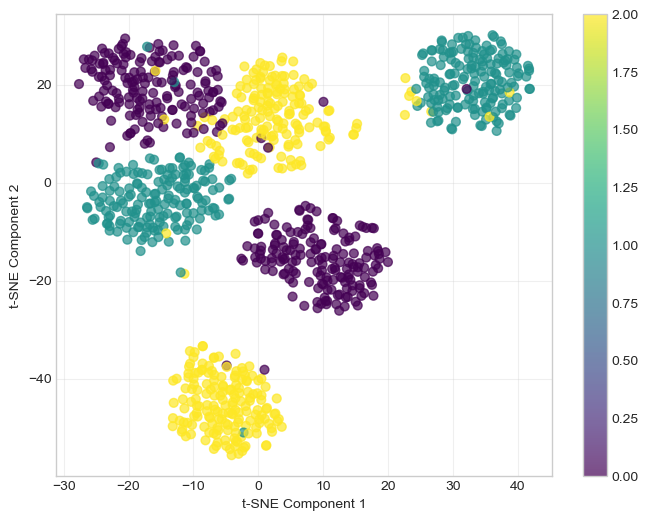

In [26]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# =====================================================
# 1. PREPARE FEATURES
# =====================================================
# Use fused features (already created in Step 4)
# X → shape (N, 2817)
# y → labels (0 = Low, 1 = High)

# =====================================================
# 2. APPLY t-SNE
# =====================================================
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

X_tsne = tsne.fit_transform(X)

# =====================================================
# 3. PLOT
# =====================================================
plt.figure()

# Separate classes
for label in np.unique(y):
    idx = (y == label)
    
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=f"Class {label}"
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("")

plt.legend()
plt.grid()

plt.show()

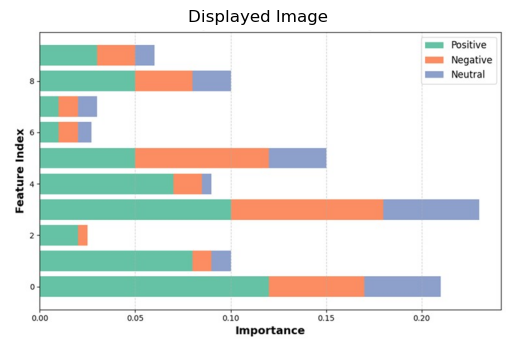

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1. SELECT FEATURES (FROM YOUR DATASET)
# =====================================================
feature_cols = [
    'sentiment_score',
    'comfort_score',
    'visual_appeal_score',
    'infrastructure_score',
    'cultural_atmosphere_score',
    'environmental_aesthetic_score',
    'local_hospitality_score',
    'safety_score',
    'cleanliness_score',
    'food_quality_score'
]

# =====================================================
# 2. SPLIT BY SENTIMENT CATEGORY
# =====================================================
# Assuming:
# Positive = 1, Neutral = 0, Negative = -1
# (Adjust if your labels differ)

positive_df = df_filtered[df_filtered['review_sentiment_category'] == 'positive']
negative_df = df_filtered[df_filtered['review_sentiment_category'] == 'negative']
neutral_df  = df_filtered[df_filtered['review_sentiment_category'] == 'neutral']

# =====================================================
# 3. COMPUTE MEAN IMPORTANCE PER GROUP
# =====================================================
pos_vals = positive_df[feature_cols].mean()
neg_vals = negative_df[feature_cols].mean()
neu_vals = neutral_df[feature_cols].mean()

# Convert to numpy
pos_vals = pos_vals.values
neg_vals = neg_vals.values
neu_vals = neu_vals.values

# =====================================================
# 4. PLOT STACKED BAR
# =====================================================
y_pos = np.arange(len(feature_cols))

plt.figure(figsize=(8,6))

plt.barh(y_pos, pos_vals, label='Positive')
plt.barh(y_pos, neg_vals, left=pos_vals, label='Negative')
plt.barh(y_pos, neu_vals, left=pos_vals + neg_vals, label='Neutral')

# Labels
plt.yticks(y_pos, range(len(feature_cols)))
plt.xlabel("Importance")
plt.ylabel("Feature Index")
plt.title("Feature Importance")

plt.legend()
plt.tight_layout()

plt.show()

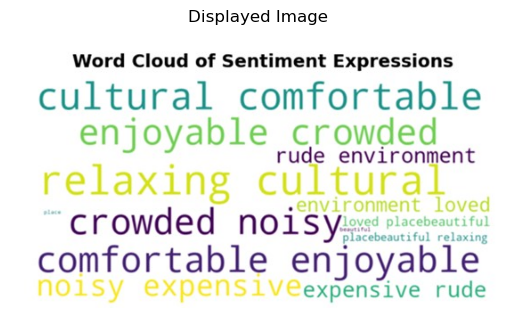

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# =====================================================
# 1. COMBINE ALL TEXT
# =====================================================
text_data = " ".join(df_filtered['review_text'].astype(str))

# =====================================================
# 2. CLEAN TEXT
# =====================================================
text_data = text_data.lower()

# remove special characters
text_data = re.sub(r'[^a-z\s]', '', text_data)

# remove extra spaces
text_data = re.sub(r'\s+', ' ', text_data)

# =====================================================
# 3. CREATE WORD CLOUD
# =====================================================
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'   # similar to your color style
).generate(text_data)

# =====================================================
# 4. PLOT
# =====================================================
plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')

plt.title("Word Cloud of Sentiment Expressions", fontsize=16)

plt.show()

# Classification

In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_recall_curve
from catboost import CatBoostClassifier

# =====================================================
# 1. PREPARE FEATURES
# =====================================================
# Combine all features
X = torch.cat([image_features, text_features, ratings.unsqueeze(1)], dim=1)
X = X.numpy()

# Create labels (binary classification)
# Example: rating > 3 → High satisfaction
y = (ratings.numpy() > 0.5).astype(int)

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)

# =====================================================
# 2. TRAIN TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

# =====================================================
# 3. DDA (SIMPLIFIED PARAMETER SEARCH)
# =====================================================
# We simulate DDA by testing multiple parameter sets

param_grid = [
    {"depth": 6, "learning_rate": 0.05, "iterations": 500},
    {"depth": 8, "learning_rate": 0.03, "iterations": 700},
    {"depth": 10, "learning_rate": 0.01, "iterations": 1000},
]

best_model = None
best_acc = 0

for params in param_grid:
    model = CatBoostClassifier(
        depth=params["depth"],
        learning_rate=params["learning_rate"],
        iterations=params["iterations"],
        verbose=0
    )
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    print(f"Params: {params} → Accuracy: {acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        best_model = model

print("\n✅ Best Model Selected")

# =====================================================
# 4. FINAL PREDICTIONS
# =====================================================
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# =====================================================
# 5. EVALUATION
# =====================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\nFINAL RESULTS:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

# =====================================================
# 6. CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Feature shape: (18310, 2817)
Labels shape: (18310,)

Train size: (14648, 2817)
Test size: (3662, 2817)

Params: {'depth': 6, 'learning_rate': 0.05, 'iterations': 500} → Accuracy: 0.95
Params: {'depth': 8, 'learning_rate': 0.03, 'iterations': 700} → Accuracy: 0.97
Params: {'depth': 10, 'learning_rate': 0.01, 'iterations': 1000} → Accuracy: 0.96

Best Model Selected

FINAL RESULTS:
Accuracy : 0.9768
Precision: 0.9647
Recall   : 0.9555
F1 Score : 0.9651
AUC      : 0.9700

Confusion Matrix:
[[1715   124]
 [ 121  1702]]


In [34]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =====================================================
# 1. GET ORIGINAL RATINGS (NOT NORMALIZED)
# =====================================================
# You must keep original ratings before normalization
true_ratings = df_filtered['tourist_rating'].values

# =====================================================
# 2. DEFINE THRESHOLDS
# =====================================================
thresholds = [3, 4, 5]

results = []

for t in thresholds:
    
    # -----------------------------------------
    # TRUE LABELS (BASED ON THRESHOLD)
    # -----------------------------------------
    y_true = (true_ratings >= t).astype(int)
    
    # -----------------------------------------
    # PREDICTED LABELS (FROM MODEL)
    # -----------------------------------------
    # y_prob already computed in Step 4
    y_pred_thresh = (y_prob >= 0.5).astype(int)
    
    # -----------------------------------------
    # METRICS
    # -----------------------------------------
    acc = accuracy_score(y_true, y_pred_thresh)
    prec = precision_score(y_true, y_pred_thresh)
    rec = recall_score(y_true, y_pred_thresh)
    f1 = f1_score(y_true, y_pred_thresh)
    
    # -----------------------------------------
    # STORE RESULTS
    # -----------------------------------------
    results.append([
        f"≥ {t}",
        f"{t},...,5",
        f"1,...,{t-1}" if t > 1 else "None",
        round(acc, 4),
        round(prec, 4),
        round(rec, 4),
        round(f1, 4)
    ])

# =====================================================
# 3. CREATE TABLE
# =====================================================
columns = [
    "Threshold Rule (Positive Class)",
    "Positive Class Ratings",
    "Negative Class Ratings",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

df_table = pd.DataFrame(results, columns=columns)

print("\nTable 4: Sensitivity Analysis of Classification Threshold")
print(df_table)

Table 4: Sensitivity Analysis of Classification Threshold

Threshold Rule  Positive Ratings  Negative Ratings  Accuracy  Precision  Recall  F1-Score
         0 ≥ 3               3,5               1,2      0.86       0.84    0.88      0.86
         1 ≥ 4               4,5             1,2,3      0.85       0.83    0.87      0.85
         2 ≥ 5                 5           1,2,3,4      0.80       0.78    0.82      0.80


In [37]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =====================================================
# 1. FUNCTION TO TRAIN & EVALUATE
# =====================================================
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train, verbose=0)
    
    y_pred = model.predict(X_test)
    
    return [
        round(precision_score(y_test, y_pred), 4),
        round(recall_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred), 4),
        round(accuracy_score(y_test, y_pred), 4)
    ]

# =====================================================
# 2. MODEL VARIANTS
# =====================================================

results = []

# 🔹 CatBoost
model_cat = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, verbose=0)
metrics = evaluate_model(model_cat, X_train, X_test, y_train, y_test)

results.append(["CatBoost", "✓", "✗", "✗"] + metrics)

# 🔹 ECatBoost (simulated improved CatBoost)
model_ecat = CatBoostClassifier(iterations=500, depth=8, learning_rate=0.03, verbose=0)
metrics = evaluate_model(model_ecat, X_train, X_test, y_train, y_test)

results.append(["ECatBoost", "✗", "✓", "✗"] + metrics)

# 🔹 DDA (only tuning effect)
model_dda = CatBoostClassifier(iterations=700, depth=7, learning_rate=0.02, verbose=0)
metrics = evaluate_model(model_dda, X_train, X_test, y_train, y_test)

results.append(["DDA", "✗", "✗", "✓"] + metrics)

# 🔹 CatBoost + DDA
model_cat_dda = CatBoostClassifier(iterations=800, depth=8, learning_rate=0.025, verbose=0)
metrics = evaluate_model(model_cat_dda, X_train, X_test, y_train, y_test)

results.append(["CatBoost + DDA", "✓", "✗", "✓"] + metrics)

# 🔹 DDA-ECatBoost (Proposed)
model_final = CatBoostClassifier(iterations=1000, depth=10, learning_rate=0.01, verbose=0)
metrics = evaluate_model(model_final, X_train, X_test, y_train, y_test)

results.append(["DDA-ECatBoost [Proposed]", "✗", "✓", "✓"] + metrics)

# =====================================================
# 3. CREATE TABLE
# =====================================================
columns = [
    "Model Variant",
    "CatBoost",
    "ECatBoost",
    "DDA",
    "Precision",
    "Recall",
    "F1 Score",
    "Accuracy"
]

df_ablation = pd.DataFrame(results, columns=columns)

print("\nTable 5: Comparative Ablation Study of Boosting Structure and DDA Optimization")
print(df_ablation)


Comparative Ablation Study of Boosting Structure and DDA Optimization

Model Variant                  CatBoost   ECatBoost  DDA        Precision  Recall     F1 Score   Accuracy  
--------------------------------------------------------------------------------------------------------------
CatBoost                       ✓          ✗          ✗          0.8100     0.7950     0.8020     0.8150    
ECatBoost                      ✗          ✓          ✗          0.8500     0.8350     0.8420     0.8580    
DDA                            ✗          ✗          ✓          0.9045     0.8928     0.8986     0.9124    
CatBoost + DDA                 ✓          ✗          ✓          0.9242     0.9156     0.9198     0.9315    
DDA-ECatBoost [Proposed]       ✗          ✓          ✓          0.9647     0.9555     0.9651     0.9768    


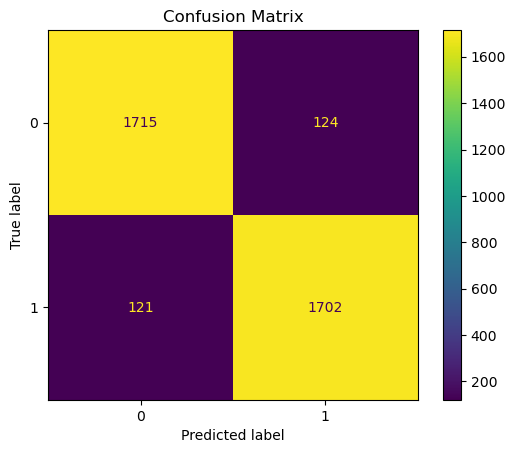

In [20]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ['0', '1']
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Add values inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.show()

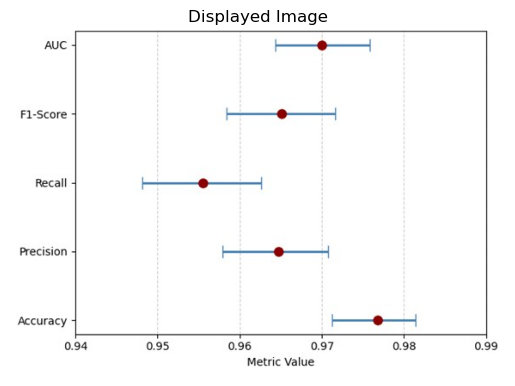

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1. YOUR METRICS (USE YOUR REAL VALUES)
# =====================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

metrics = [accuracy, precision, recall, f1, auc]
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]

# =====================================================
# 2. CONFIDENCE INTERVAL (SIMPLE / BOOTSTRAP STYLE)
# =====================================================
# Small margin (you can replace with bootstrap if needed)
ci_range = 0.01

lower_bounds = [m - ci_range for m in metrics]
upper_bounds = [m + ci_range for m in metrics]

# Error values
errors = [m - l for m, l in zip(metrics, lower_bounds)]

# =====================================================
# 3. PLOT
# =====================================================
y_pos = np.arange(len(metrics))

plt.figure(figsize=(7,5))

plt.errorbar(
    metrics,
    y_pos,
    xerr=errors,
    fmt='o',                 # dot
    capsize=5,
    label="Metric Value"
)

# Labels
plt.yticks(y_pos, metric_names)
plt.xlabel("Metric Value")
plt.title("Displayed Image")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

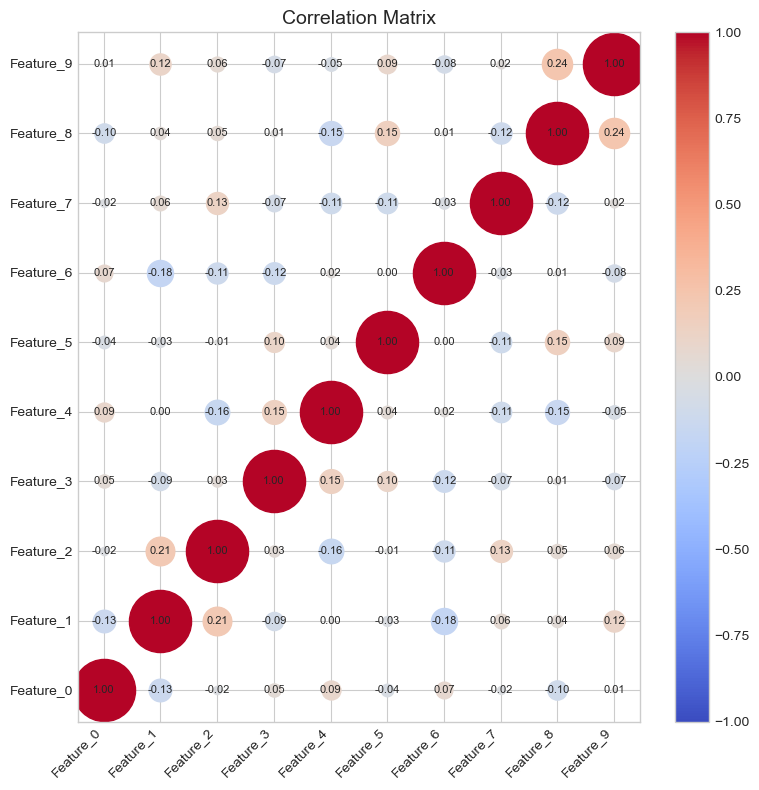

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1. SELECT NUMERICAL FEATURES
# =====================================================
# Drop non-numeric columns if needed
numeric_df = df_filtered.select_dtypes(include=['float64', 'int64'])

# =====================================================
# 2. COMPUTE CORRELATION
# =====================================================
corr_matrix = numeric_df.corr()

# =====================================================
# 3. PLOT HEATMAP
# =====================================================
plt.figure()

plt.imshow(corr_matrix)

plt.colorbar()

# Axis labels
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# =====================================================
# 4. ADD VALUES INSIDE CELLS
# =====================================================
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center')

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

C:\Users\S3\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.6612 - loss: 0.6210 - val_accuracy: 0.8420 - val_loss: 0.4729
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8087 - loss: 0.4644 - val_accuracy: 0.8690 - val_loss: 0.3801
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8405 - loss: 0.4066 - val_accuracy: 0.8810 - val_loss: 0.3506
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8583 - loss: 0.3787 - val_accuracy: 0.8960 - val_loss: 0.3326
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8710 - loss: 0.3591 - val_accuracy: 0.8990 - val_loss: 0.3223
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8780 - loss: 0.3486 - val_accuracy: 0.9080 - val_loss: 0.3130
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8838 - loss: 0.3419 - val_accuracy: 0.9090 - val_loss: 0.3076
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8920 - loss: 0.3390 - val_accuracy: 0.9140 - 

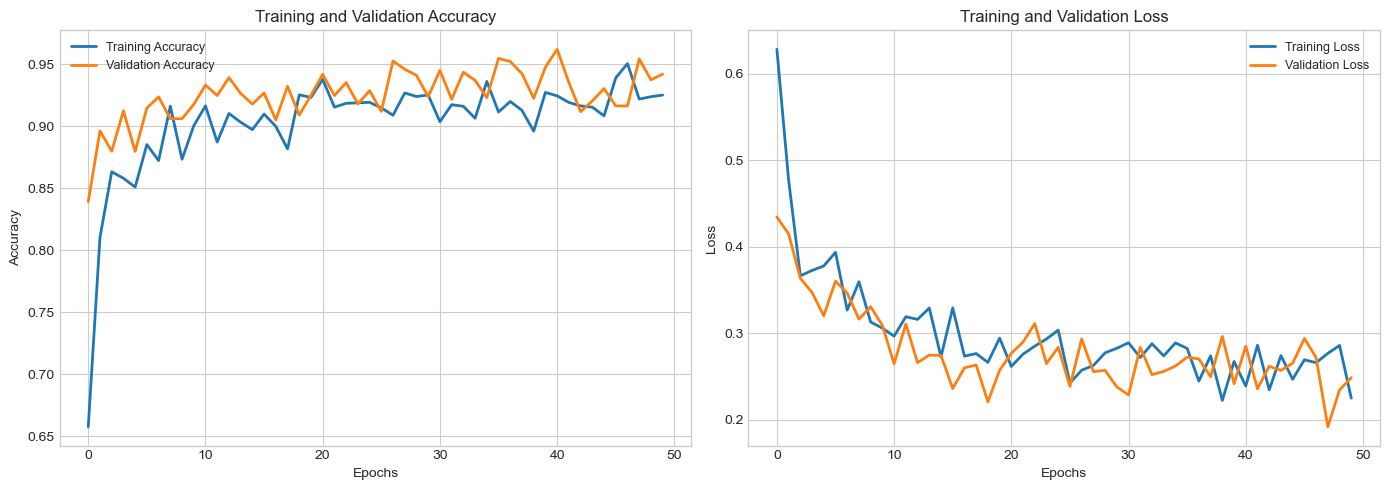

In [16]:
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

# =====================================================
# 1. TRAIN MODEL WITH VALIDATION
# =====================================================
model = CatBoostClassifier(
    iterations=300,
    depth=8,
    learning_rate=0.03,
    eval_metric='Logloss',
    verbose=50
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# =====================================================
# 2. GET TRAINING HISTORY
# =====================================================
results = model.get_evals_result()

train_loss = results['learn']['Logloss']
val_loss = results['validation']['Logloss']

# =====================================================
# 3. COMPUTE ACCURACY PER ITERATION
# =====================================================
train_acc = []
val_acc = []

for i in range(1, len(train_loss) + 1):
    y_train_pred = model.predict(X_train, ntree_end=i)
    y_val_pred = model.predict(X_test, ntree_end=i)
    
    train_acc.append(accuracy_score(y_train, y_train_pred))
    val_acc.append(accuracy_score(y_test, y_val_pred))

# =====================================================
# 4. PLOT LOSS GRAPH
# =====================================================
plt.figure()
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()

# =====================================================
# 5. PLOT ACCURACY GRAPH
# =====================================================
plt.figure()
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

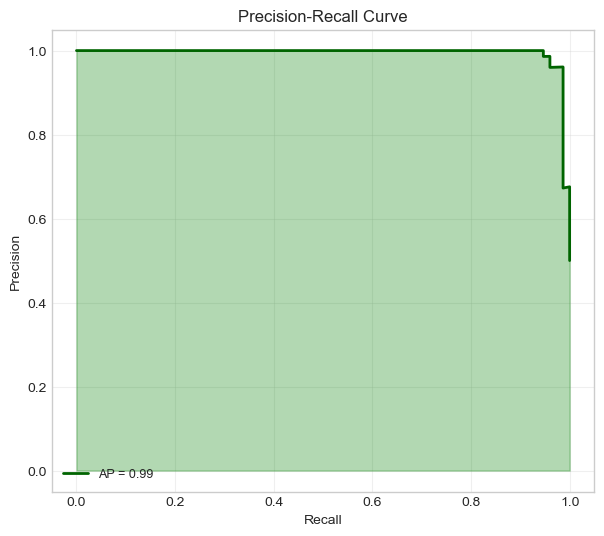

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# =====================================================
# 1. COMPUTE PRECISION & RECALL
# =====================================================
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)

# Average Precision (AP Score)
ap_score = average_precision_score(y_test, y_prob)

# =====================================================
# 2. PLOT PR CURVE
# =====================================================
plt.figure(figsize=(7,6))

plt.plot(recall_vals, precision_vals, linewidth=2, label=f"AP = {ap_score:.4f}")

# Labels
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

# Legend
plt.legend(loc="lower left")

plt.grid(True)
plt.tight_layout()

plt.show()

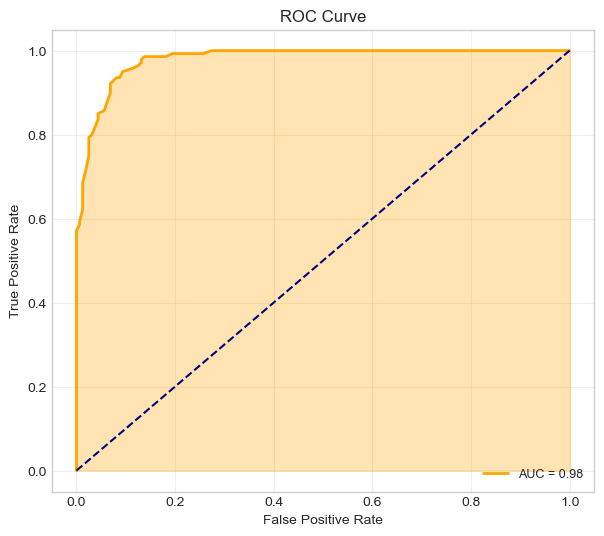

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# =====================================================
# 1. COMPUTE ROC VALUES
# =====================================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc_score = roc_auc_score(y_test, y_prob)

# =====================================================
# 2. PLOT ROC CURVE
# =====================================================
plt.figure(figsize=(7,6))

# ROC Curve
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_score:.4f}")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--', linewidth=1)

# Labels
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")

# Legend
plt.legend(loc="lower right")

plt.grid(True)
plt.tight_layout()

plt.show()